In [127]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [81]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [82]:
# Checking for nulls

df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [83]:
#Checking relevant columns

df.columns

newdf = df.drop(columns=["CustomerId", "Surname", "RowNumber"])

newdf.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


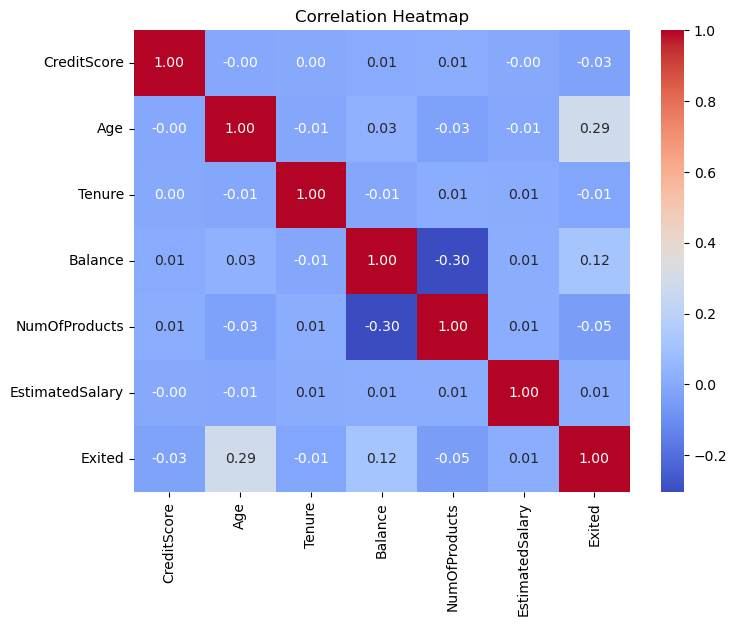

In [119]:
#Using a heatmap to check the correlation between all variables.

numeric_df = df[["CreditScore", "Age", "Tenure", "Balance", 
                 "NumOfProducts", "EstimatedSalary", "Exited"]]

corr = numeric_df.corr()

# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()


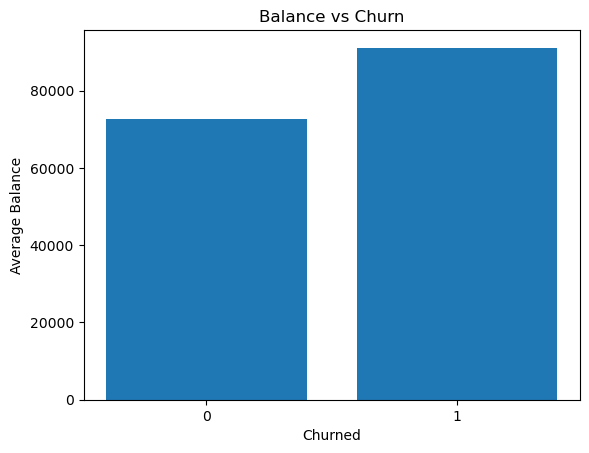

Key Insight: 
Wealthier customers( >$80,000 ) of this bank tend to churn more than moderate to wealthy customers. This is an indication 
that this bank lags in providing better investment opportunities to the very wealthy
customers( $80,000 - $60,000), such as higher interest rates, investment products, or wealth-management services, 
This bank is doing a great job keeping its moderately wealthy customers happy, while not 
sufficing in plans for their wealthiest customers.

Key Indication: The bank can use a threshold financial services mechanism to attract and keep
wealthiest customers


In [140]:
#Checking Balance relationship to Exited 

X = df["Exited"]
Y = df["Balance"]

avg_balance = df.groupby("Exited")["Balance"].mean()

plt.bar(avg_balance.index.astype(str), avg_balance.values)  
plt.xlabel("Churned")
plt.ylabel("Average Balance")
plt.title("Balance vs Churn")
plt.show()

print("Key Insight: ")

print("""Wealthier customers( >$80,000 ) of this bank tend to churn more than moderate to wealthy customers. This is an indication 
that this bank lags in providing better investment opportunities to the very wealthy
customers( $80,000 - $60,000), such as higher interest rates, investment products, or wealth-management services, 
This bank is doing a great job keeping its moderately wealthy customers happy, while not 
sufficing in plans for their wealthiest customers.

Key Indication: The bank can use a threshold financial services mechanism to attract and keep
wealthiest customers""")



In [136]:

churned = df[df['Exited'] == 1]['Balance']
not_churned = df[df['Exited'] == 0]['Balance']

t_stat, p_value = ttest_ind(churned, not_churned, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

mean1, mean2 = churned.mean(), not_churned.mean()
std1, std2 = churned.std(), not_churned.std()
n1, n2 = len(churned), len(not_churned)

s_pooled = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))

cohens_d = (mean1 - mean2) / s_pooled
print("Cohen's d:", cohens_d)


t-statistic: 12.471280320050688
p-value: 6.318663518527974e-35
Cohen's d: 0.29636961846423865


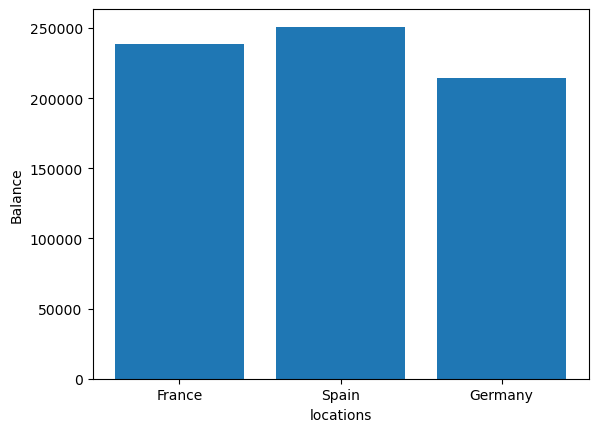

In [139]:
X = df["Geography"]
Y = df["Balance"]

plt.figure()
plt.bar(X,Y)
plt.xlabel("locations")
plt.ylabel("Balance")
plt.show()

#All locations have a high and fair distribution of balance, but Germany is lacking behind
#No insights for balance vs credit score, is active, has credit card



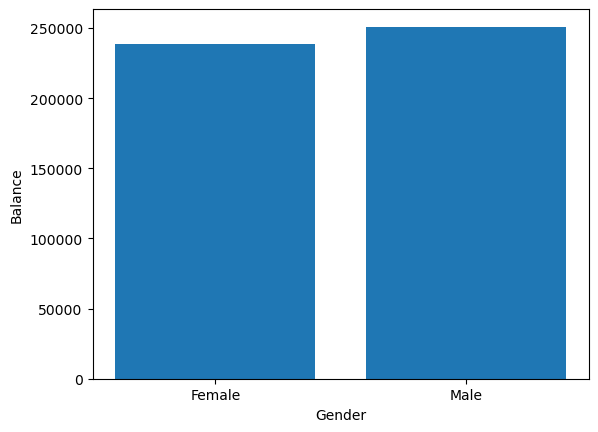

In [90]:
#Test 2: Balance vs Gender Insights:

X = df["Gender"]
Y = df["Balance"]

plt.figure()
plt.bar(X,Y)
plt.xlabel("Gender")
plt.ylabel("Balance")
plt.show()

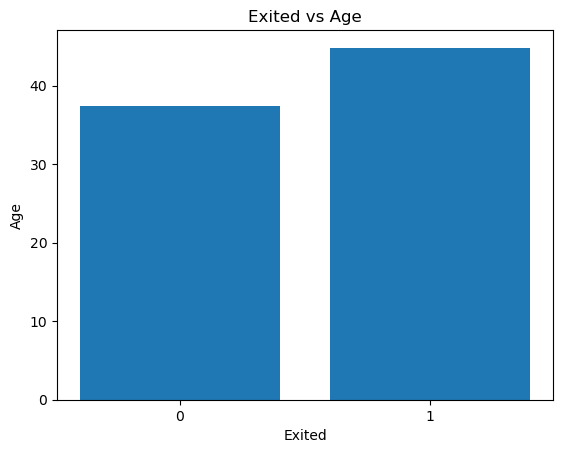

In [95]:
X = df["Exited"]
Y = df["Age"]

avg_balance = df.groupby("Exited")["Age"].mean()

plt.bar(avg_balance.index.astype(str), avg_balance.values) 
plt.xlabel("Exited")
plt.ylabel("Age")
plt.title("Exited vs Age")
plt.show()

In [126]:
churned = df[df['Exited'] == 1]['Age']
not_churned = df[df['Exited'] == 0]['Age']

t_stat, p_value = ttest_ind(churned, not_churned, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

mean1, mean2 = churned.mean(), not_churned.mean()
std1, std2 = churned.std(), not_churned.std()
n1, n2 = len(churned), len(not_churned)

s_pooled = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))

cohens_d = (mean1 - mean2) / s_pooled
print("Cohen's d:", cohens_d)


t-statistic: 30.419197204406792
p-value: 4.7127272656641046e-179
Cohen's d: 0.7390919905296035


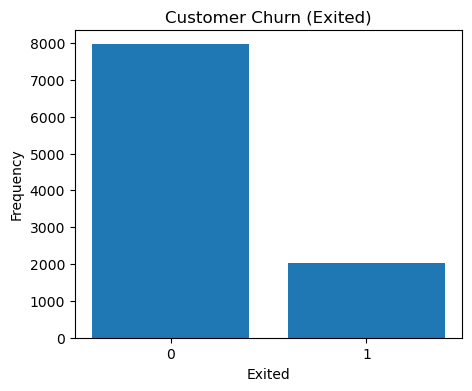

In [132]:
counts = df["Exited"].value_counts().sort_index()  # ensures 0 then 1
plt.figure(figsize=(5,4))
plt.bar(counts.index, counts.values, tick_label=[0,1])
plt.title("Customer Churn (Exited)")
plt.xlabel("Exited")
plt.ylabel("Frequency")
plt.show()

In [77]:
pd.crosstab(df["HasCrCard"], df["Exited"], normalize="columns")

#Insight: 69.91% people exited have a credit card and 70.7146% of people who did not exit also have a credit card

Exited,0,1
HasCrCard,,
0,0.292854,0.300933
1,0.707146,0.699067


In [78]:
pd.crosstab(df["IsActiveMember"], df["Exited"], normalize="columns")

#Insight: 63.9175% people exited are inactive members, 55.5% who did not exit are active members

Exited,0,1
IsActiveMember,,
0,0.445435,0.639175
1,0.554565,0.360825


In [128]:
table = pd.crosstab(df['Exited'], df['HasCrCard'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p)
print("Expected Frequencies:\n", expected)


Chi-square Statistic: 0.4713377990444081
Degrees of Freedom: 1
p-value: 0.49237236141554686
Expected Frequencies:
 [[2345.1035 5617.8965]
 [ 599.8965 1437.1035]]


In [129]:
table = pd.crosstab(df['Exited'], df['IsActiveMember'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p)
print("Expected Frequencies:\n", expected)

n = table.sum().sum()  # total sample size
min_dim = min(table.shape) - 1  # denominator term
cramers_v = np.sqrt(chi2 / (n * min_dim))

print("Cramer's V:", cramers_v)




Chi-square Statistic: 242.98534164287963
Degrees of Freedom: 1
p-value: 8.785858269303703e-55
Expected Frequencies:
 [[3861.2587 4101.7413]
 [ 987.7413 1049.2587]]
Cramer's V: 0.15587987094005423


In [130]:
table = pd.crosstab(df['Exited'], df['Gender'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p)
print("Expected Frequencies:\n", expected)

n = table.sum().sum()  # total sample size
min_dim = min(table.shape) - 1  # denominator term
cramers_v = np.sqrt(chi2 / (n * min_dim))

print("Cramer's V:", cramers_v)


Chi-square Statistic: 112.91857062096116
Degrees of Freedom: 1
p-value: 2.2482100097131755e-26
Expected Frequencies:
 [[3617.5909 4345.4091]
 [ 925.4091 1111.5909]]
Cramer's V: 0.10626315006669113


In [131]:
table = pd.crosstab(df['Exited'], df['Geography'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p)
print("Expected Frequencies:\n", expected)

n = table.sum().sum()  # total sample size
min_dim = min(table.shape) - 1  # denominator term
cramers_v = np.sqrt(chi2 / (n * min_dim))


Chi-square Statistic: 301.2553368243453
Degrees of Freedom: 2
p-value: 3.830317605354266e-66
Expected Frequencies:
 [[3992.6482 1997.9167 1972.4351]
 [1021.3518  511.0833  504.5649]]
